# Facial Emotions Recognition System

##  Importing the Libraries

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O 
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from sklearn.metrics import accuracy_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
import random
import torch


random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} for inference")

Using cuda for inference


## Loading the Dataset

In [3]:
# Path to the directory
data= pd.read_csv('D:\\Minor2_FERSystem\\Dataset\\fer2013.csv')

## Dataset Overview

In [4]:
data.shape

(35887, 3)

In [5]:
data.isnull().sum()

emotion    0
pixels     0
Usage      0
dtype: int64

In [6]:
# first 5 row of data
data.head(5)

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [7]:
#check usage values
#80% training, 10% validation and 10% test
data.Usage.value_counts()

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

In [8]:
#check target labels
emotion_map= {0:'Angry', 1:'Disgust',2: 'Fear', 3:'Happy', 4:'Sad', 5:'Surprise', 6:'Neutral'}
emotion_counts = data['emotion'].value_counts(sort=False).reset_index()
emotion_counts.columns =['emotion', 'number']
emotion_counts['emotion']= emotion_counts['emotion'].map(emotion_map)
emotion_counts

,emotion,number
0,Angry,4953
1,Fear,5121
2,Sad,6077
3,Neutral,6198
4,Happy,8989
5,Surprise,4002
6,Disgust,547


## Data Analysis (Graphical Representation)

###  BarGraph

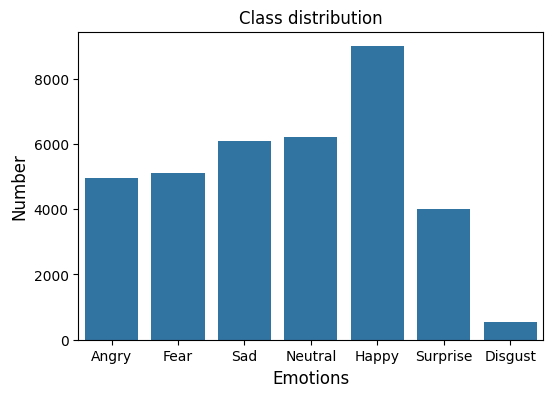

In [9]:
# Plotting a bar graph
plt.figure(figsize=(6,4))
sns.barplot(x=emotion_counts.emotion, y=emotion_counts.number)
plt.title('Class distribution')
plt.ylabel('Number', fontsize=12)
plt.xlabel('Emotions', fontsize=12)
plt.show()

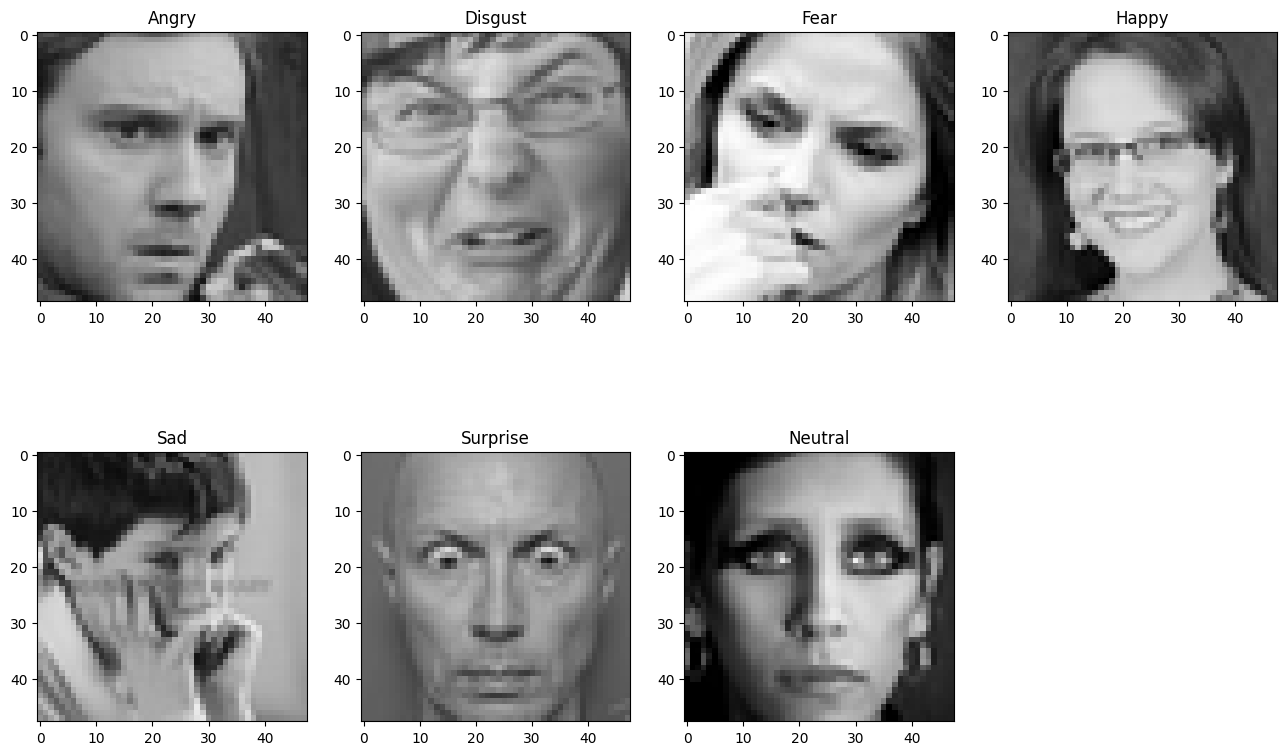

In [10]:
def row2image(row):
    pixels, emotion = row['pixels'], emotion_map[row['emotion']]
    img= np.array(pixels.split(), dtype='float32')
    img= img.reshape(48,48)
    image =np.zeros((48,48,3))
    image[:,:,0]= img
    image[:,:,1]= img
    image[:,:,2]= img
    return image.astype(np.uint8), emotion

plt.figure(0, figsize=(16,10))
for i in range(1,8):
    face = data[data['emotion']==i-1].iloc[0]
    img, label =row2image(face)
    plt.subplot(2,4,i)
    plt.imshow(img)
    plt.title(label)

plt.show()

## Pre-processing data

### Shuffling the data

In [11]:
data= data.sample(frac=1)

### One Hot Encoding

In [12]:
labels= to_categorical(data[['emotion']],num_classes=7)

In [13]:
#Changing image pixels to Numpy array
train_pixels = data["pixels"].astype(str).str.split(" ").tolist()
train_pixels = np.uint8(train_pixels)

###  Standardization

In [14]:
# StandartScaler() function takes only 2 dimensional array as i/p,
# we reshape the data then apply our scaler to make the mean zero and standart deviation as unit.
pixels = train_pixels.reshape((35887*2304,1))

In [15]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
pixels =scaler.fit_transform(pixels)

### Reshaping the data (48,48)

In [16]:
pixels= train_pixels.reshape((35887, 48, 48,1))

### Train test validation split

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(pixels, labels, test_size=0.1, shuffle=False)
X_train, X_val, y_train, y_val= train_test_split(X_train, y_train, test_size=0.1, shuffle=False)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(29068, 48, 48, 1)
(3589, 48, 48, 1)
(3230, 48, 48, 1)


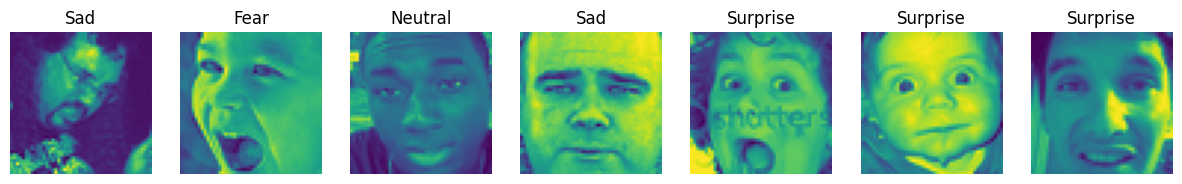

In [19]:
# train data contains one sample of each class.
plt.figure(figsize=(15,23))
label_dict= {0:'Angry', 1:'Disgust', 2:'Fear', 3 :'Happiness', 4: 'Sad', 5: 'Surprise', 6:'Neutral'}
i= 1
for i in range (7):
    img=np.squeeze(X_train[i])
    plt.subplot(1,7,i+1)
    plt.imshow(img)
    index= np.argmax(y_train[i])
    plt.title(label_dict[index])
    plt.axis('off')
    i+= 1
plt.show()

## Data augmentation using ImageDataGenerator

In [20]:
datagen= ImageDataGenerator(width_shift_range= 0.1,
                               height_shift_range=0.1,
                               horizontal_flip=True,
                               zoom_range=0.2)
valgen= ImageDataGenerator(width_shift_range= 0.1,
                               height_shift_range =0.1,
                               horizontal_flip=True,
                               zoom_range=0.2)

In [21]:
datagen.fit(X_train)
valgen.fit(X_val)

In [22]:
train_generator= datagen.flow(X_train, y_train, batch_size=64)
val_generator= datagen.flow(X_val, y_val, batch_size=64)

## Building CNN Model

### Designing a model

In [23]:
def cnn_model():

  model= tf.keras.models.Sequential()
  model.add(Input(shape=(48,48,1)))

  model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
  model.add(Conv2D(64,(3,3), padding='same', activation='relu' ))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(128,(3,3), padding='same', activation='relu'))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(256,(3,3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Flatten())
  model.add(Dense(256,activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.4))

  model.add(Dense(7, activation='softmax'))
  model.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
  return model

In [24]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten,Dense,Dropout,BatchNormalization,MaxPooling2D,Activation,Input
from tensorflow.keras import regularizers
model= cnn_model()


In [25]:
model.compile(
    optimizer= Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,007 (10.50 MB)

 Trainable params: 2,750,599 (10.49 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Early stopping Technique

Adding checkpointer to implement Early Stopping to prevent overfitting.

In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
checkpointer = [EarlyStopping(monitor= 'val_accuracy', verbose=1,
                              restore_best_weights=True,mode="max",patience= 5),
                ModelCheckpoint('best_model.h5',monitor="val_accuracy",verbose=1,
                                save_best_only=True,mode="max")]

In [28]:
history = model.fit(train_generator,
                    epochs=20,
                    batch_size=64,
                    verbose=1,
                    callbacks=checkpointer,
                    validation_data=val_generator)

Epoch 1/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.2013 - loss: 4.2299
Epoch 1: val_accuracy improved from None to 0.29969, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 192s 413ms/step - accuracy: 0.2276 - loss: 3.9977 - val_accuracy: 0.2997 - val_loss: 3.4136
Epoch 2/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.2719 - loss: 3.6191
Epoch 2: val_accuracy improved from 0.29969 to 0.33777, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 230s 504ms/step - accuracy: 0.2802 - loss: 3.5324 - val_accuracy: 0.3378 - val_loss: 3.2519
Epoch 3/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.3105 - loss: 3.2504
Epoch 3: val_accuracy improved from 0.33777 to 0.35759, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 188s 413ms/step - accuracy: 0.3205 - loss: 3.1694 - val_accuracy: 0.3576 - val_loss: 2.9368
Epoch 4/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.3482 - loss: 2.9340
Epoch 4: val_accuracy improved from 0.35759 to 0.39195, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 228s 502ms/step - accuracy: 0.3518 - loss: 2.8698 - val_accuracy: 0.3920 - val_loss: 2.6193
Epoch 5/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.3728 - loss: 2.6683
Epoch 5: val_accuracy improved from 0.39195 to 0.41517, saving model to best_model.h5


...


Epoch 11: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 280s 581ms/step - accuracy: 0.4786 - loss: 1.6798 - val_accuracy: 0.5056 - val_loss: 1.5588
Epoch 12/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.4837 - loss: 1.6167
Epoch 12: val_accuracy did not improve from 0.50557
455/455 ━━━━━━━━━━━━━━━━━━━━ 255s 560ms/step - accuracy: 0.4880 - loss: 1.6052 - val_accuracy: 0.4941 - val_loss: 1.6129
Epoch 13/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.5020 - loss: 1.5478
Epoch 13: val_accuracy improved from 0.50557 to 0.51300, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 252s 554ms/step - accuracy: 0.5004 - loss: 1.5441 - val_accuracy: 0.5130 - val_loss: 1.5058
Epoch 14/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.5012 - loss: 1.5088
Epoch 14: val_accuracy did not improve from 0.51300
455/455 ━━━━━━━━━━━━━━━━━━━━ 240s 528ms/step - accuracy: 0.5036 - loss: 1.4984 - val_accuracy: 0.5102 - val_loss: 1.4749
Epoch 15/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5146 - loss: 1.4628
Epoch 15: val_accuracy did not improve from 0.51300
455/455 ━━━━━━━━━━━━━━━━━━━━ 185s 406ms/step - accuracy: 0.5139 - loss: 1.4540 - val_accuracy: 0.5040 - val_loss: 1.4977
Epoch 16/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5217 - loss: 1.4216
Epoch 16: val_accuracy improved from 0.51300 to 0.53746, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 187s 410ms/step - accuracy: 0.5227 - loss: 1.4150 - val_accuracy: 0.5375 - val_loss: 1.4180
Epoch 17/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.5334 - loss: 1.3844
Epoch 17: val_accuracy did not improve from 0.53746
455/455 ━━━━━━━━━━━━━━━━━━━━ 182s 400ms/step - accuracy: 0.5328 - loss: 1.3852 - val_accuracy: 0.5291 - val_loss: 1.4063
Epoch 18/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.5344 - loss: 1.3685
Epoch 18: val_accuracy improved from 0.53746 to 0.54768, saving model to best_model.h5



Epoch 18: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 212s 465ms/step - accuracy: 0.5345 - loss: 1.3658 - val_accuracy: 0.5477 - val_loss: 1.3761
Epoch 19/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.5464 - loss: 1.3342
Epoch 19: val_accuracy improved from 0.54768 to 0.56285, saving model to best_model.h5



Epoch 19: finished saving model to best_model.h5
455/455 ━━━━━━━━━━━━━━━━━━━━ 216s 475ms/step - accuracy: 0.5431 - loss: 1.3396 - val_accuracy: 0.5628 - val_loss: 1.3066
Epoch 20/20
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.5504 - loss: 1.3124
Epoch 20: val_accuracy did not improve from 0.56285
455/455 ━━━━━━━━━━━━━━━━━━━━ 195s 429ms/step - accuracy: 0.5462 - loss: 1.3102 - val_accuracy: 0.5560 - val_loss: 1.3376
Restoring model weights from the end of the best epoch: 19.


## Visualizing Results

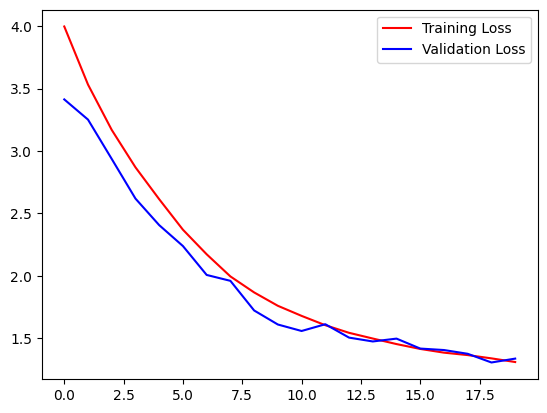

In [29]:
plt.plot(history.history["loss"],'r', label="Training Loss")
plt.plot(history.history["val_loss"],'b', label="Validation Loss")
plt.legend()

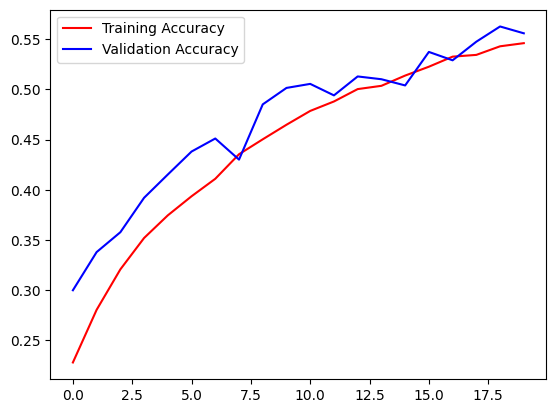

In [30]:
plt.plot(history.history["accuracy"],'r',label="Training Accuracy")
plt.plot(history.history["val_accuracy"],'b',label="Validation Accuracy")
plt.legend()

In [31]:
loss= model.evaluate(X_test,y_test)
print("Test Acc: " + str(loss[1]))

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5921 - loss: 1.2477
Test Acc: 0.592086911201477


In [32]:
preds= model.predict(X_test)
y_pred=np.argmax(preds , axis = 1 )

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step


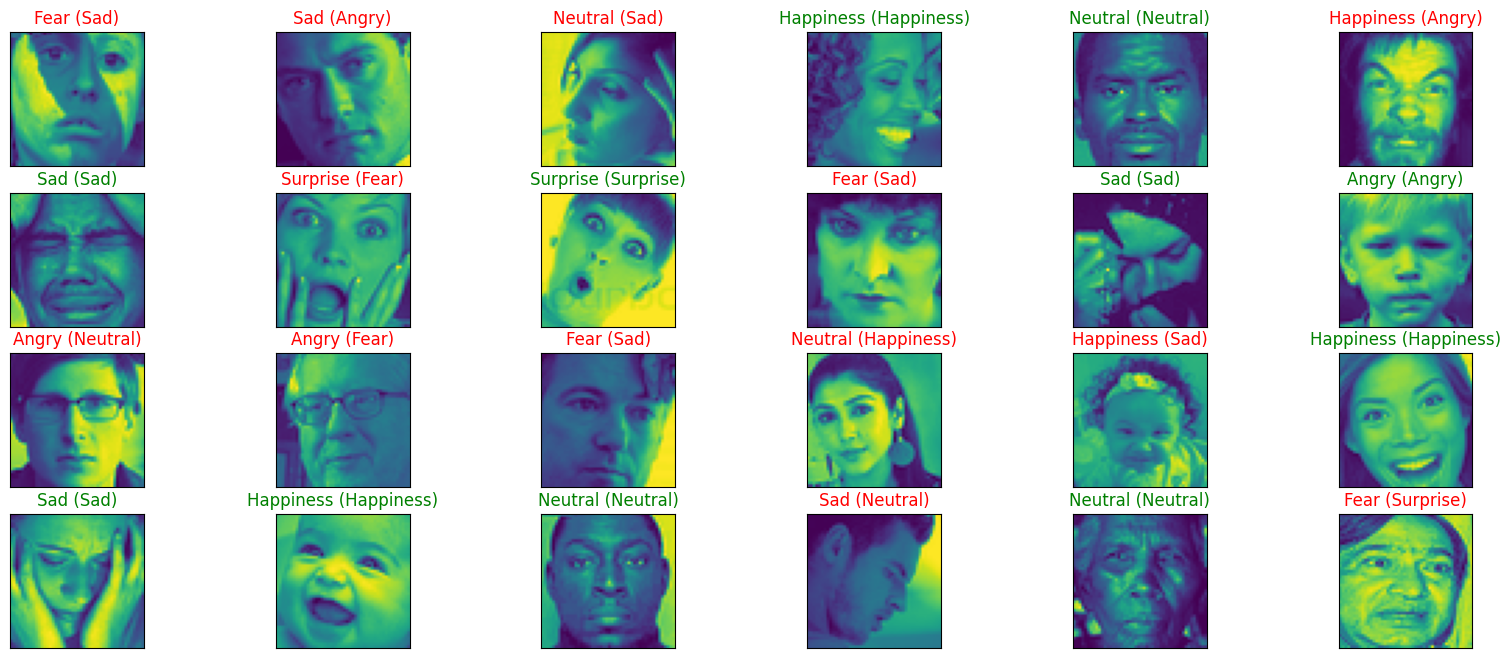

In [33]:
label_dict= {0 :'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happiness', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

figure= plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(X_test.shape[0], size=24, replace=False)):
    ax=figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_test[index]))
    predict_index=label_dict[(y_pred[index])]
    true_index =label_dict[np.argmax(y_test,axis=1)[index]]

    ax.set_title("{} ({})".format((predict_index),
                                  (true_index)),
                                  color=("green" if predict_index==true_index else "red"))

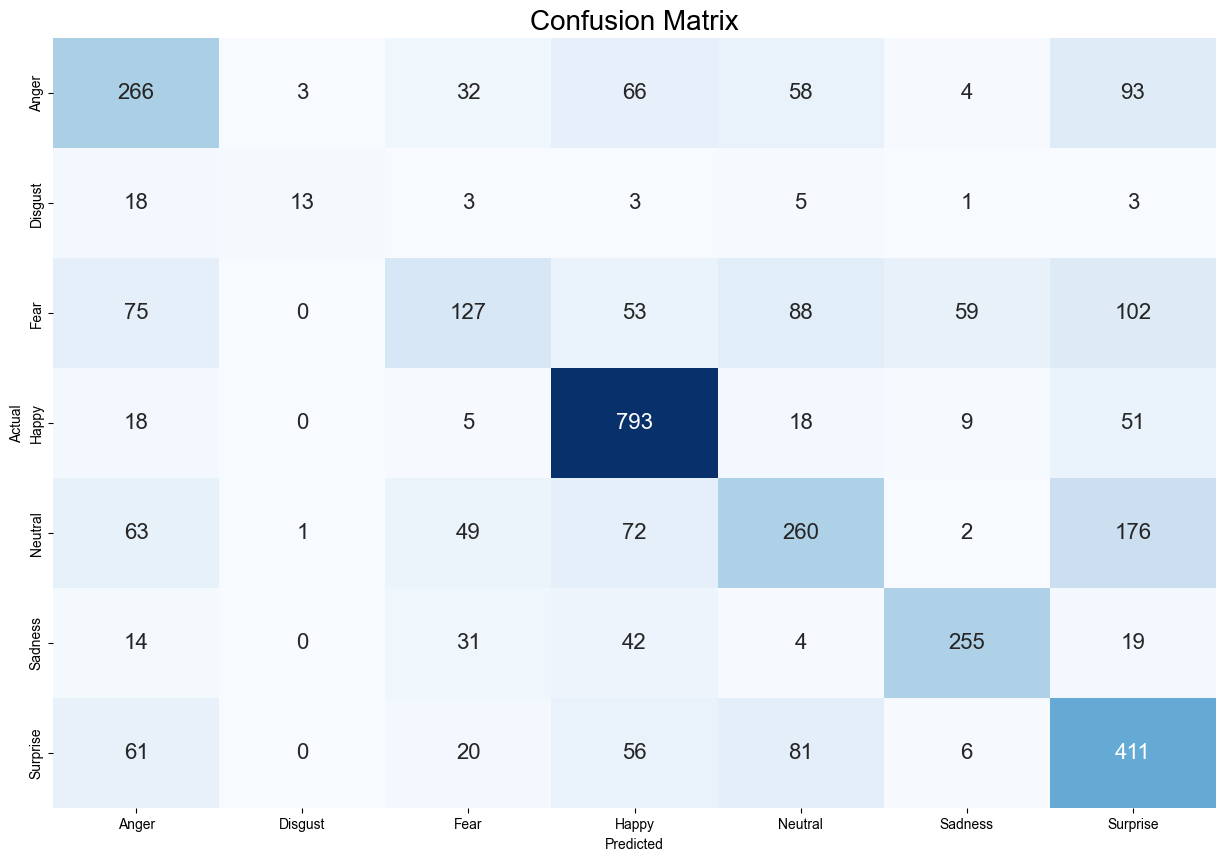

In [34]:
CLASS_LABELS= ['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', "Surprise"]

cm_data= confusion_matrix(np.argmax(y_test, axis = 1 ), y_pred)
cm=pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
cm.index.name='Actual'
cm.columns.name='Predicted'
plt.figure(figsize=(15,10))
plt.title('Confusion Matrix',fontsize = 20)
sns.set(font_scale=1.2)
ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

In [35]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis= 1 ),y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.517     0.510     0.513       522
           1      0.765     0.283     0.413        46
           2      0.476     0.252     0.329       504
           3      0.731     0.887     0.801       894
           4      0.506     0.417     0.457       623
           5      0.759     0.699     0.728       365
           6      0.481     0.647     0.552       635

    accuracy                          0.592      3589
   macro avg      0.605     0.528     0.542      3589
weighted avg      0.584     0.592     0.577      3589



## Saving the Model

In [36]:
#import pickle library
import pickle
filename='model.h5'
pickle.dump(history,open(filename,'wb'))

## Working Demo (Webcam Feed)

In [37]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from collections import deque

# Load model
model = load_model("best_model.h5")

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

cap = cv2.VideoCapture(0)

emotion_buffer = deque(maxlen=10)

print("Press 'q' to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 3)

    for (x, y, w, h) in faces:
        face = gray[y:y+h, x:x+w]

        face_resized = cv2.resize(face, (48, 48))

        # Improve lighting
        face_resized = cv2.equalizeHist(face_resized)

        face_normalized = face_resized / 255.0
        face_reshaped = np.reshape(face_normalized, (1, 48, 48, 1))

        prediction = model.predict(face_reshaped, verbose=0)

        confidence = np.max(prediction)
        emotion_index = np.argmax(prediction)

        if confidence < 0.5:
            emotion = "Uncertain"
        else:
            emotion_buffer.append(emotion_index)
            smoothed_emotion = max(set(emotion_buffer), key=emotion_buffer.count)
            emotion = emotion_labels[smoothed_emotion]

        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.putText(frame, f"{emotion} ({confidence:.2f})",
                    (x, y-10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (0,255,0), 2)

    cv2.imshow('FER Live', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Press 'q' to quit
